# **Data Loading**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("retail_sales_cleaned.csv")

print(df.head())

   Transaction ID Customer ID Product Category    Product Name  Quantity  \
0          100932       C0503        Groceries  Cooking Oil 1L       2.0   
1          101309       C0339   Home & Kitchen      Frying Pan       3.0   
2          100397       C0535         Clothing        Sneakers       4.0   
3          100538       C0224      Electronics     USB-C Cable       3.0   
4          100791       C0223   Home & Kitchen      Frying Pan       5.0   

   Unit Price  Total Amount Purchase Date Customer City Payment Method  
0     1729.13       3458.26    2024-08-16        Quetta     Debit Card  
1    10892.87      32678.61    2025-09-09      Peshawar  Mobile Wallet  
2     2668.91      10675.64    2024-12-10     Hyderabad  Bank Transfer  
3    72429.71     217289.13    2025-12-28     Islamabad    Credit Card  
4     6636.68      33183.40    2025-04-15        Quetta    Credit Card  


In [3]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
df["Month"] = df["Purchase Date"].dt.to_period("M").astype(str)
df["DayOfWeek"] = df["Purchase Date"].dt.day_name()

print(f"Revenue: {df['Total Amount'].sum():,.0f}  |  Orders: {len(df)}  |  AOV: {df['Total Amount'].mean():,.2f}")

Revenue: 69,139,894  |  Orders: 1700  |  AOV: 40,670.53


# **Exploratory Data Analysis**

# Monthly Sales Trend:

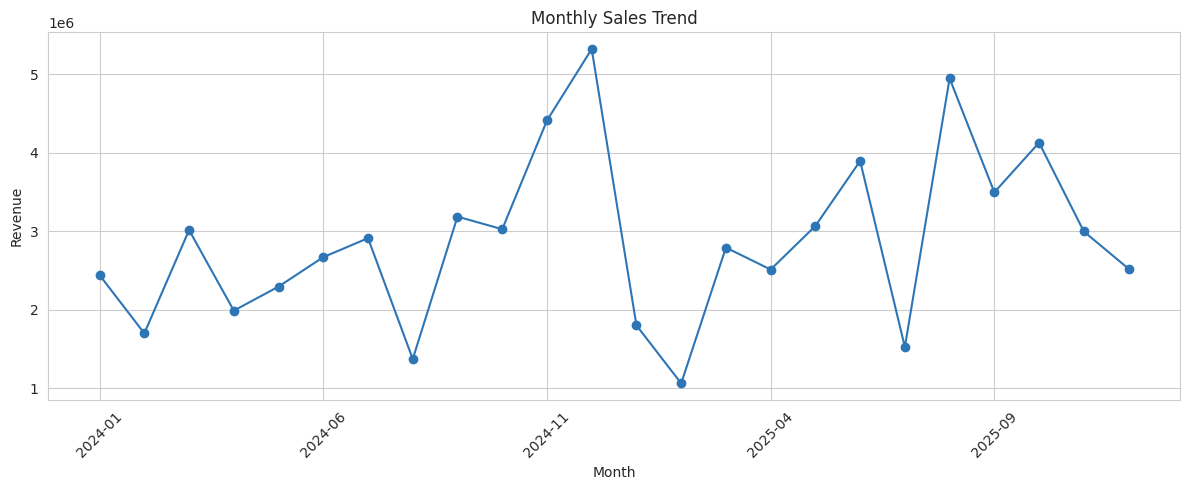

In [4]:
monthly = df.groupby("Month")["Total Amount"].sum()
plt.figure(figsize=(12,5))
monthly.plot(marker="o", color="#2E75B6")
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top Selling Products:

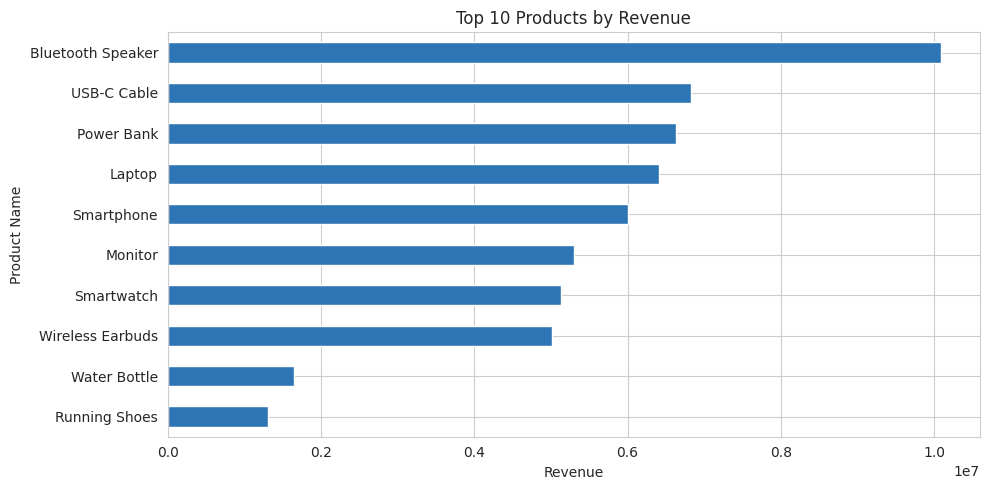

In [5]:
top_products = df.groupby("Product Name")["Total Amount"].sum().sort_values(ascending=False).head(10)
top_products.sort_values().plot(kind="barh", color="#2E75B6")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

# Top Performing Categories:

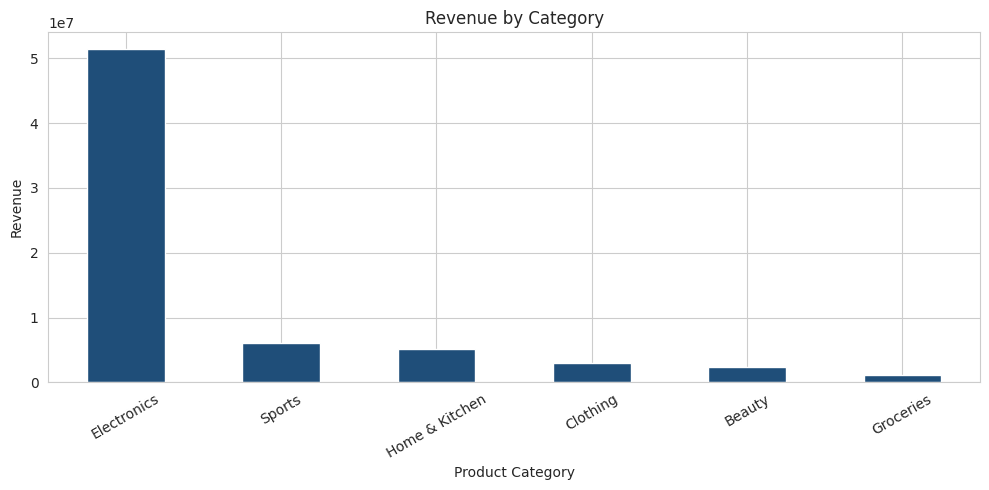

In [7]:
cat = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)
cat.plot(kind="bar", color="#1F4E79")
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Revenue By City:

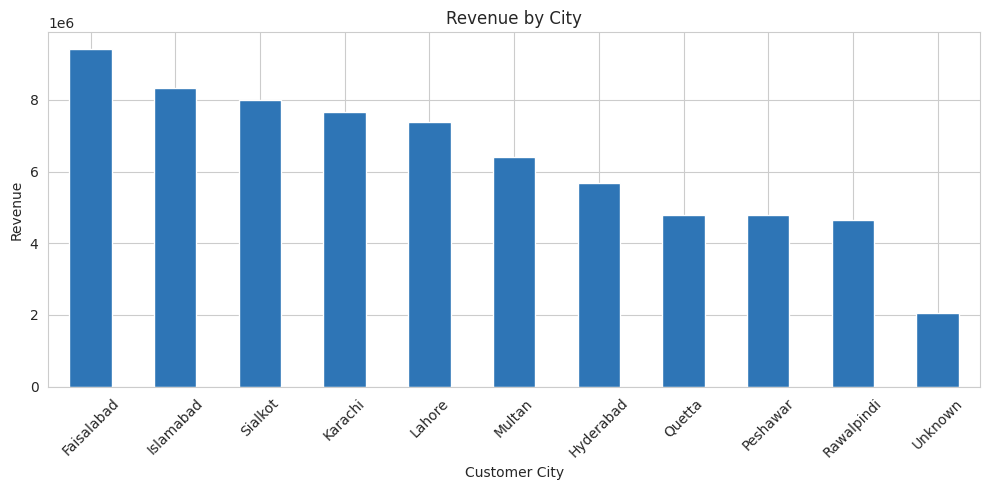

In [8]:
city = df.groupby("Customer City")["Total Amount"].sum().sort_values(ascending=False)
city.plot(kind="bar", color="#2E75B6")
plt.title("Revenue by City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Customer Purchasing Patterns:

Avg orders per customer: 2.93
Repeat customers: 461 of 580


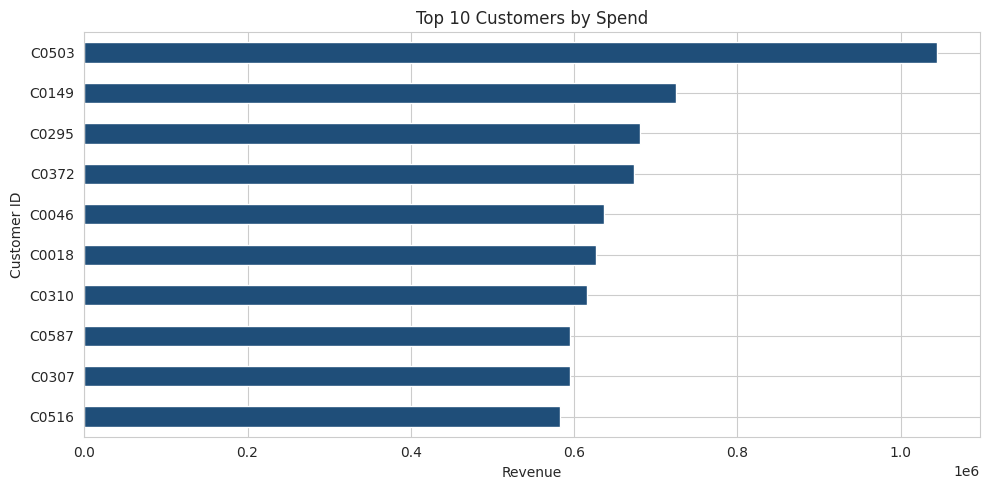

In [9]:
cust_orders = df.groupby("Customer ID").size()
print(f"Avg orders per customer: {cust_orders.mean():.2f}")
print(f"Repeat customers: {(cust_orders>1).sum()} of {len(cust_orders)}")

top_cust = df.groupby("Customer ID")["Total Amount"].sum().sort_values(ascending=False).head(10)
top_cust.sort_values().plot(kind="barh", color="#1F4E79")
plt.title("Top 10 Customers by Spend")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

# Payment Method Distribution:

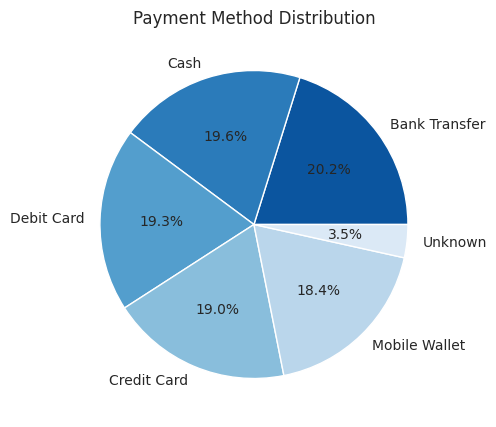

In [11]:
pay = df["Payment Method"].value_counts()
plt.pie(pay, labels=pay.index, autopct="%1.1f%%", colors=sns.color_palette("Blues_r", len(pay)))
plt.title("Payment Method Distribution")
plt.show()

# Average Order Value:

Overall AOV: 40,670.53


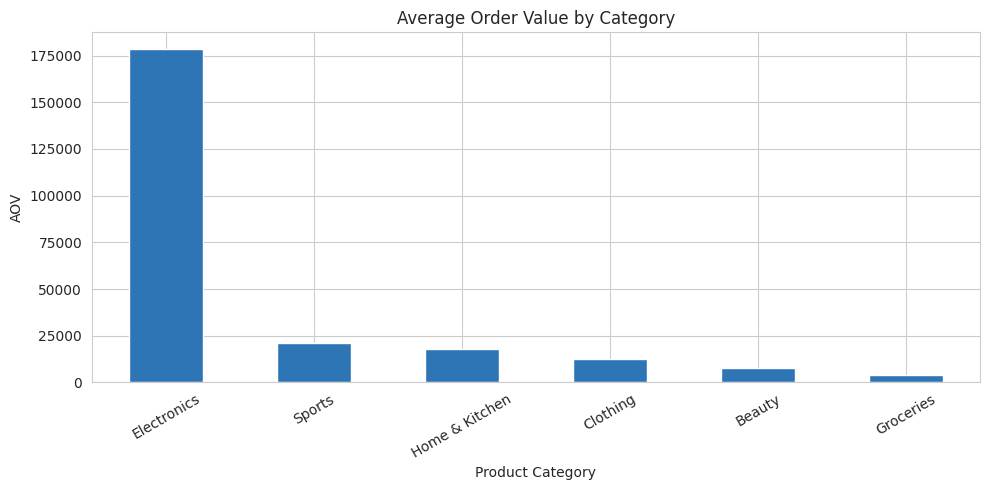

In [12]:
aov_overall = df["Total Amount"].mean()
aov_by_cat = df.groupby("Product Category")["Total Amount"].mean().sort_values(ascending=False)
print(f"Overall AOV: {aov_overall:,.2f}")
aov_by_cat.plot(kind="bar", color="#2E75B6")
plt.title("Average Order Value by Category")
plt.ylabel("AOV")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Peak Sales Periods

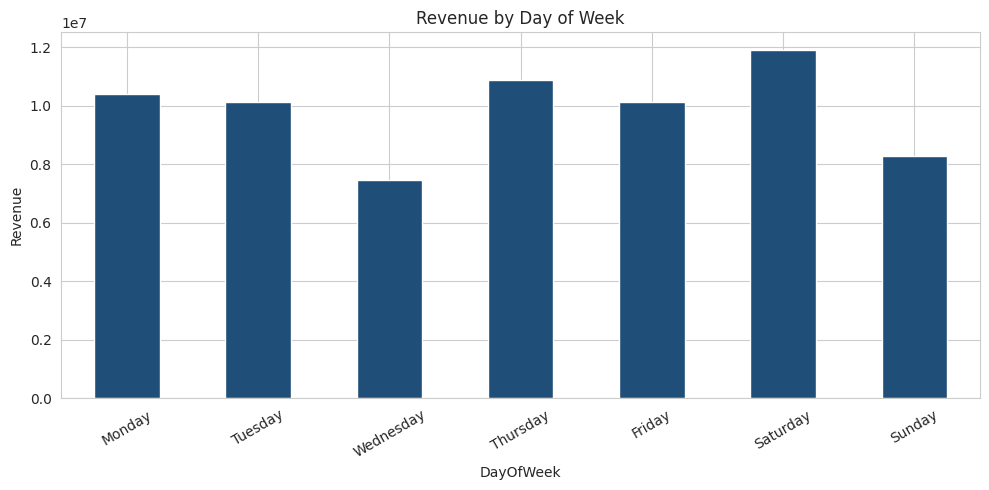

In [13]:
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = df.groupby("DayOfWeek")["Total Amount"].sum().reindex(dow_order)
dow.plot(kind="bar", color="#1F4E79")
plt.title("Revenue by Day of Week")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()